In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np
import spacy

In [2]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 41.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
# Load spaCy's pre-trained model
!python -m spacy download en_core_web_md
nlp = spacy.load("en_core_web_md")

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.8.0/en_core_web_md-3.8.0-py3-none-any.whl (33.5 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


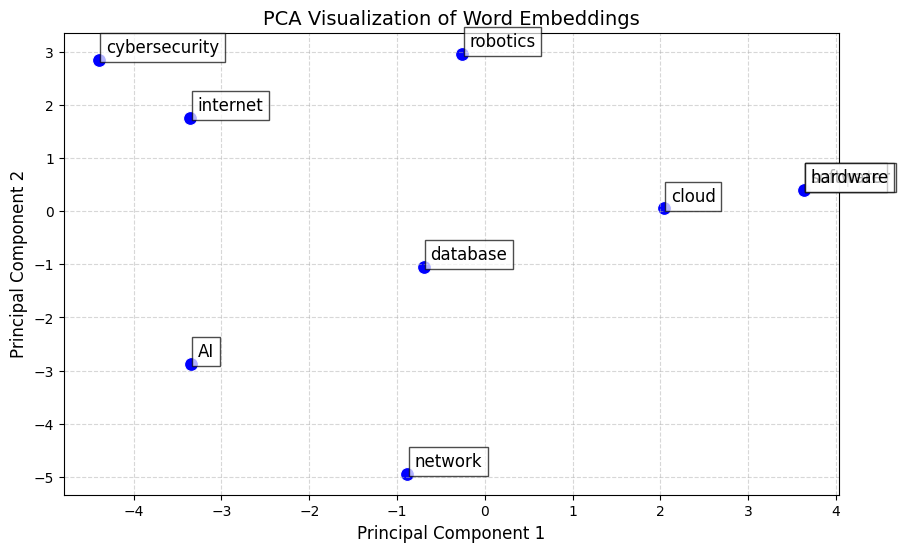

In [4]:



# Select 10 words from the "Technology" domain
tech_words = ["computer", "internet", "software", "hardware", "network",
              "AI", "cloud", "cybersecurity", "database", "robotics"]


# Extract word vectors
word_vectors = np.array([nlp(word).vector for word in tech_words])


# Apply PCA for 2D visualization
pca_result = PCA(n_components=2).fit_transform(word_vectors)


# Improved Visualization
plt.figure(figsize=(10, 6))  # Increase figure size
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], s=100, color="blue")


# Annotate words clearly
for i, word in enumerate(tech_words):
    plt.annotate(word, (pca_result[i, 0], pca_result[i, 1]),

    fontsize=12, xytext=(5,5), textcoords="offset points", bbox=dict(facecolor='white', alpha=0.7))

# Avoid overlap

# Add title, labels, and grid
plt.title("PCA Visualization of Word Embeddings", fontsize=14)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)  # Light grid for clarity
plt.show()
